# DeepLense Classical Baseline
## ML4Sci GSoC 2026 — Specific Test III: Quantum ML

Classical ML baselines for dark matter substructure classification 
using strong gravitational lensing maps.

### Classes
- 0: No Substructure
- 1: Subhalo Substructure  
- 2: Vortex Substructure

### Approach
Images resized to 32x32, flattened to 1024-dim vectors, reduced via PCA,
then classified with Random Forest. Evaluated using ROC curve and AUC score.

### Dataset
DeepLense dataset (not included). Images are min-max normalized.

In [22]:
import os 
import numpy as np
import cv2 as cv
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [23]:
train_path = "dataset/train"

X_train = []
y_train = []
for label, class_folder in enumerate(sorted(os.listdir(train_path))):
    class_path = os.path.join(train_path, class_folder)
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)
            img =np.load(file_path)
            img = img[0]
            img = cv.resize(img,(32,32))
            img = img.astype(np.float32)/255.0
            features = img.flatten()
            X_train.append(features)
            y_train.append(label)
X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(30000, 1024)
(30000,)


In [24]:
train_path = "dataset/val"

X_val = []
y_val = []

for label, class_folder in enumerate(sorted(os.listdir(train_path))):
    class_path = os.path.join(train_path, class_folder)
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)
            img =np.load(file_path)
            img = img[0]
            img = cv.resize(img,(32,32))
            img = img.astype(np.float32)/255.0
            features = img.flatten()
            X_val.append(features)
            y_val.append(label)
            

X_val = np.array(X_val)
y_val = np.array(y_val)

In [27]:
pca=PCA(n_components=200)
X_reduced = pca.fit_transform(X_train)

model = RandomForestClassifier(n_estimators=400, max_depth=20)
model.fit(X_reduced,y_train)
X_val_reduced = pca.transform(X_val)

predictions = model.predict(X_val_reduced)

In [ ]:
print(classification_report(y_val, predictions, 
      target_names=['No Substructure', 'Subhalo', 'Vortex']))

                 precision    recall  f1-score   support

No Substructure       0.43      0.61      0.51      2500
        Subhalo       0.37      0.28      0.32      2500
         Vortex       0.42      0.35      0.38      2500

       accuracy                           0.41      7500
      macro avg       0.41      0.41      0.40      7500
   weighted avg       0.41      0.41      0.40      7500



BEST CLASSICAL MODEL:
Random Forest (n_estimators=400, max_depth=20)
PCA = 200
Accuracy ≈ 41.1%
CLASSICAL MODEL:
Random Forest (n_estimators=400, max_depth=20)
PCA = 8
Accuracy ≈ 37%

Classes detected: ['No Substructure', 'Subhalo', 'Vortex']


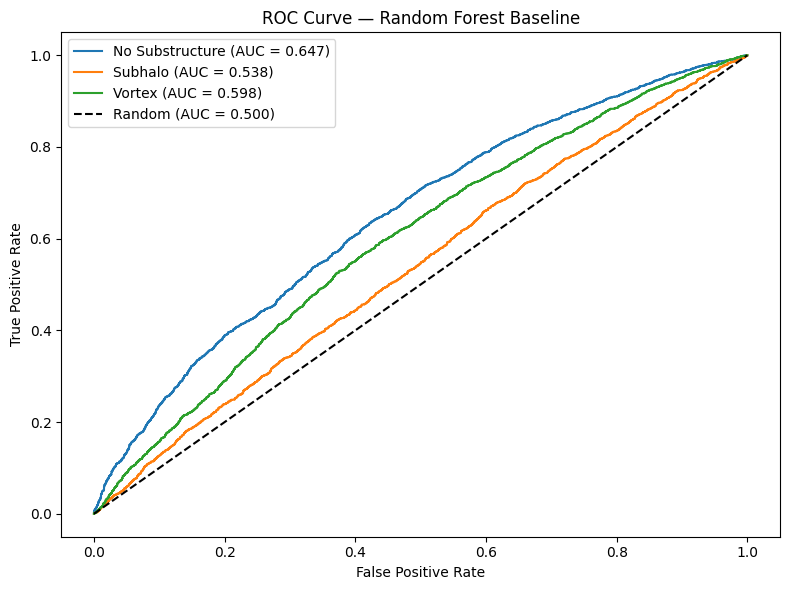

Mean AUC: 0.594


In [35]:
y_bin = label_binarize(y_val, classes=[0, 1, 2])
y_scores = model.predict_proba(X_val_reduced)
classes = ['No Substructure', 'Subhalo', 'Vortex']
print("Classes detected:", classes)


plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Baseline')
plt.legend()
plt.tight_layout()
plt.savefig('roc_classical_rf.png', dpi=150)
plt.show()

aucs = []
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
    aucs.append(auc(fpr, tpr))

print(f"Mean AUC: {np.mean(aucs):.3f}")

## Results Summary

| Model | Accuracy | Mean AUC |
|---|---|---|
| Random Forest (n=400, depth=20) + PCA(200) | 41.1% | 0.594 |

### Per-Class AUC
| Class | AUC |
|---|---|
| No Substructure | 0.647 |
| Subhalo | 0.538 |
| Vortex | 0.598 |

**Observation:** No Substructure is the most distinguishable class. 
Subhalo and Vortex substructures are harder to separate using 
raw pixel features, motivating the quantum feature extraction approach.